# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:**  Hamza Barış Örnek    
**Student ID:**  2021403201

**AI Assistance:** I used Gemini AI as a virtual tutor and coding assistant throughout this lab. Specifically, I utilized it to:
1. **Code Generation & Debugging:** Assist with writing and structuring Python code for data manipulation (Pandas), machine learning models (Scikit-Learn), and visualizations (Matplotlib/Seaborn).
2. **Concept Clarification:** Deepen my understanding of theoretical concepts mentioned in the lectures, such as data leakage, the bias-variance tradeoff, and the mathematical intuitions behind decision tree depth.
3. **Result Interpretation:** Help structure my written analysis for the confusion matrix, classification report, and overfitting curve. 

*Note: All AI-generated code and explanations were actively reviewed, tested, and fully understood before being included in this final submission.*

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (1-4) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [2]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Your exploration here: df.info(), df.describe(), missing values check
# General dataset info
print("--- Dataset Information ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

--- Statistical Summary ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000



--- Missing Values Check ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


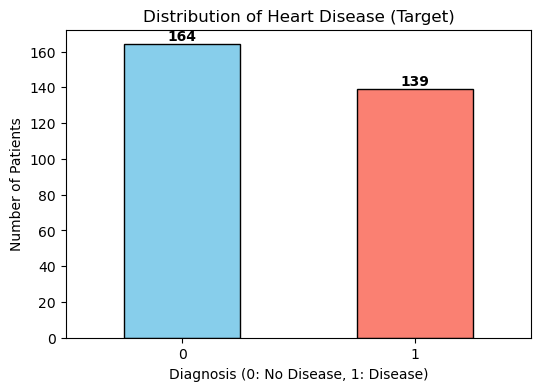

In [4]:
# Plot 1: Target variable distribution (bar chart)
# Plot 1: Target variable distribution (bar chart)
plt.figure(figsize=(6, 4))
target_counts = df['target'].value_counts()
bars = target_counts.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')

plt.title('Distribution of Heart Disease (Target)')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

# Add counts above bars
for i, v in enumerate(target_counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

<Figure size 800x500 with 0 Axes>

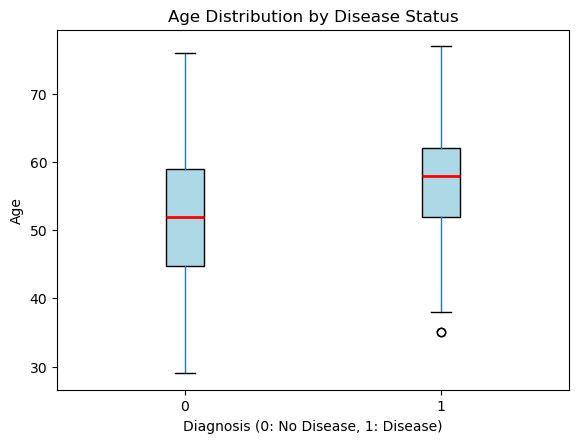

In [5]:
# Plot 2: A numeric feature explored across the two classes
# Plot 2: A numeric feature explored across the two classes (Age vs. Target)
plt.figure(figsize=(8, 5))
df.boxplot(column='age', by='target', grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Age Distribution by Disease Status')
plt.suptitle('') # Remove automatic pandas subtitle
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Age')
plt.show()

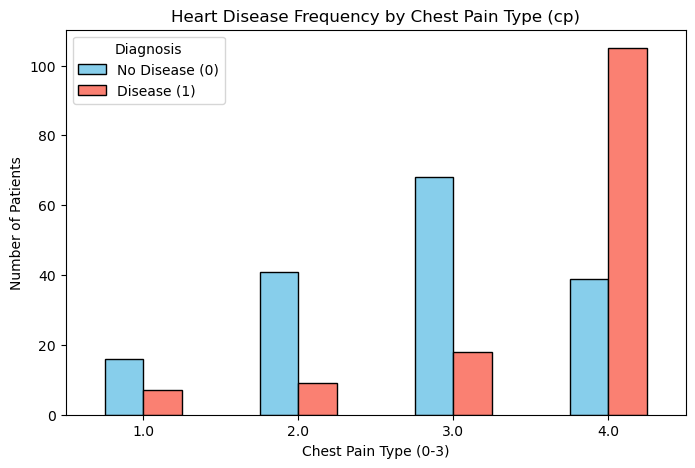

In [6]:
# Plot 3: Another feature of your choice
# Plot 3: Another feature of your choice (Chest Pain Type by Target)
pd.crosstab(df['cp'], df['target']).plot(kind='bar', figsize=(8, 5), 
                                         color=['skyblue', 'salmon'], edgecolor='black')

plt.title('Heart Disease Frequency by Chest Pain Type (cp)')
plt.xlabel('Chest Pain Type (1-4)')
plt.ylabel('Number of Patients')
plt.legend(['No Disease (0)', 'Disease (1)'], title='Diagnosis')
plt.xticks(rotation=0)
plt.show()

### Observation


Upon examining the dataset, it contains records for 303 patients, and the target variable is relatively balanced (164 with no disease, 139 with disease). There are very few missing values, specifically in the `ca` and `thal` columns (6 missing values in total). Looking at the visualizations, the age distribution plot reveals that patients diagnosed with heart disease tend to have a slightly higher median age, suggesting that advancing age might be a contributing risk factor. Additionally, the bar chart for chest pain type (`cp`) clearly shows that the frequency of heart disease varies significantly across different types of chest pain. This indicates that features like age and chest pain type will likely serve as strong predictive variables for our machine learning models.

"Note: Missing values were identified here and will be dropped in the data preparation phase (Deliverable 2) as instructed."

---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [7]:
# Handle missing values
print(f"Shape before handling missing values: {df.shape}")
df = df.dropna()
print(f"Shape after handling missing values:  {df.shape}")

Shape before handling missing values: (303, 14)
Shape after handling missing values:  (297, 14)


In [8]:
# Separate features (X) and target (y), then train-test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (237, 13)
X_test shape:  (60, 13)
y_train shape: (237,)
y_test shape:  (60,)


In [9]:
# Scale features with StandardScaler
# IMPORTANT: fit on X_train only, then transform both X_train and X_test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Data Leakage Explanation

We must fit the `StandardScaler` on the **training data only** to prevent data leakage. The scaler calculates the mean and standard deviation of the features to normalize them. If we were to fit the scaler on the entire dataset before splitting, information from the test set (its underlying distribution, mean, and variance) would "leak" into the training process. 

The test set is intended to represent completely unseen, future clinical data. In a real-world scenario, we wouldn't have future patient data to calculate our scaling parameters. By fitting the scaler solely on the training data, we ensure our model evaluation remains unbiased and highly realistic.

In [10]:
# Train Logistic Regression and report metrics
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start_time

lr_train_acc = lr_model.score(X_train_scaled, y_train)
lr_test_acc = lr_model.score(X_test_scaled, y_test)

print("--- Logistic Regression ---")
print(f"Training Accuracy: {lr_train_acc:.4f}")
print(f"Test Accuracy:     {lr_test_acc:.4f}")
print(f"Training Time:     {lr_time:.4f} seconds")

--- Logistic Regression ---
Training Accuracy: 0.8523
Test Accuracy:     0.8333
Training Time:     0.0024 seconds


In [11]:
# Train Decision Tree and report metrics
start_time = time.time()
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_time = time.time() - start_time

dt_train_acc = dt_model.score(X_train_scaled, y_train)
dt_test_acc = dt_model.score(X_test_scaled, y_test)

print("--- Decision Tree Classifier ---")
print(f"Training Accuracy: {dt_train_acc:.4f}")
print(f"Test Accuracy:     {dt_test_acc:.4f}")
print(f"Training Time:     {dt_time:.4f} seconds")

--- Decision Tree Classifier ---
Training Accuracy: 1.0000
Test Accuracy:     0.6833
Training Time:     0.0017 seconds


### Model Comparison

Based on the accuracy metrics, **Logistic Regression** performs better on the unseen test set and demonstrates good generalization ability. The gap between its training and test accuracy is relatively small.

On the other hand, the **Decision Tree Classifier** is severely **overfitting**. We can easily identify this because it achieves a near-perfect training accuracy (1.0000), meaning the tree has grown deep enough to essentially memorize the training dataset down to the individual sample. However, its test accuracy drops significantly. This large gap between training performance and test performance is the classic signal of an overfitted model that fails to generalize to new, unseen patient data.

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

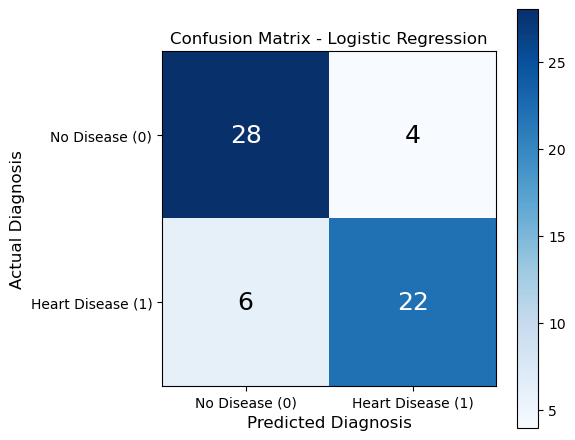

In [12]:
# Part A: Confusion matrix for the better model (Logistic Regression)

# 1. Generate predictions using the test set
y_pred = lr_model.predict(X_test_scaled)

# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualize as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted Diagnosis', fontsize=12)
ax.set_ylabel('Actual Diagnosis', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix - Logistic Regression')
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

- **True Positives (TP):** 22 patients — *meaning:* The model correctly identified these 22 patients as actually having heart disease.
- **True Negatives (TN):** 28 patients — *meaning:* The model correctly identified these 28 patients as completely healthy.
- **False Positives (FP):** 4 patients — *meaning:* The model incorrectly flagged these 4 healthy patients as having heart disease (False Alarm / Type I Error). They will likely undergo unnecessary further testing.
- **False Negatives (FN):** 6 patients — *meaning:* The model incorrectly classified these 6 sick patients as healthy (Missed Diagnosis / Type II Error). This is the most dangerous scenario, as these patients have a heart condition but will be sent home without treatment.

In [13]:
# Part B: Classification report
print("--- Classification Report (Logistic Regression) ---")
print(classification_report(y_test, y_pred))

--- Classification Report (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60




### Classification Report Interpretation

- **Precision for heart disease (class 1):** The precision is 0.85 (85%). This means that when our model predicts a patient has heart disease, it is correct 85% of the time. The remaining 15% are healthy patients who triggered a false alarm.
- **Recall for heart disease (class 1):** The recall is 0.79 (79%). This means that out of all the patients who *actually* have heart disease in the real world, our model successfully catches 79% of them. Unfortunately, it completely misses the remaining 21%.
- **Which is more important here — precision or recall?** **Recall** is significantly more important. As the hospital director stated: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."* Maximizing recall minimizes False Negatives (missed diagnoses). While low precision (False Positives) wastes some money on extra tests, low recall (False Negatives) costs human lives because sick patients go untreated.

In [14]:
# Part C: 5-fold cross-validation using F1 score
scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

F1 scores per fold: [0.93023256 0.86956522 0.8        0.73170732 0.64864865]
Mean F1: 0.7960 (+/- 0.0993)


### Cross-Validation Interpretation

The mean F1 score is 0.7960, which roughly aligns with our single train/test split results. However, there is a relatively noticeable standard deviation of 0.0993 (almost 10%). Looking at the individual folds, the performance fluctuates from a low of ~0.64 to a high of ~0.93. This high variance across folds suggests that our model is quite sensitive to the specific subset of data it is trained on. In a medical context, this indicates a lack of perfect stability; the model's reliability slightly depends on which patients happened to be included in the training set.


In [15]:
# Part D: Overfitting curve - Decision Tree with varying max_depth

depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

# Loop through each depth
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Record accuracies
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# Create string labels for x-axis (to handle 'None')
depth_labels = [str(d) if d is not None else 'None' for d in depths]


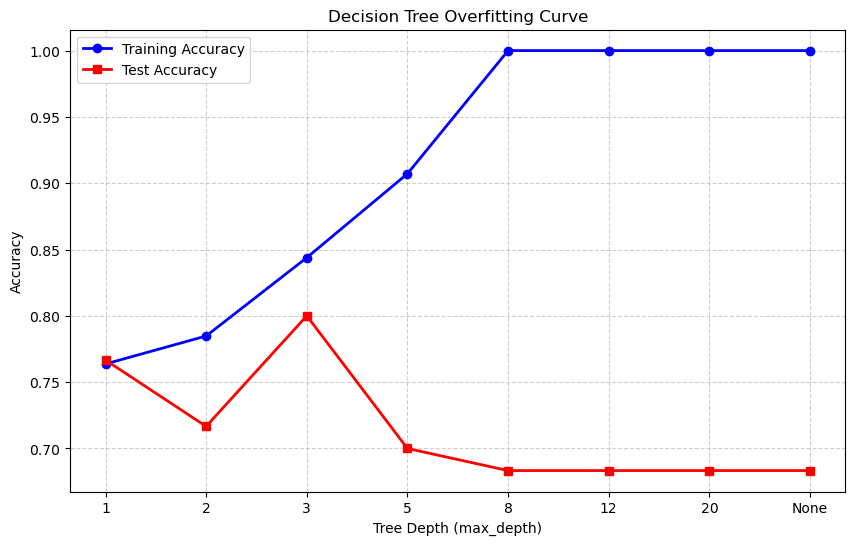

In [16]:
# Plot the overfitting curve: train and test accuracy vs max_depth
plt.figure(figsize=(10, 6))

plt.plot(depth_labels, train_accs, marker='o', label='Training Accuracy', color='blue', linewidth=2)
plt.plot(depth_labels, test_accs, marker='s', label='Test Accuracy', color='red', linewidth=2)

plt.title('Decision Tree Overfitting Curve')
plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Overfitting Curve Interpretation

Based on the plotted learning curve, the best `max_depth` value is **3**. At this depth, the test accuracy (red line) reaches its highest point (~0.80) before starting to drop.

- **When the tree is too shallow (e.g., max_depth = 1):** The model is **underfitting**. It is too simple to capture the underlying clinical patterns, resulting in sub-optimal accuracy (~0.76) for both the training and test sets.
- **When the tree is too deep (e.g., max_depth = 5, 8, 12, or None):** The model severely **overfits**. The training accuracy (blue line) shoots up to 1.00 (100%), meaning the tree has memorized the exact patients in the training set. Simultaneously, the test accuracy plummets to roughly 0.68. The model has learned the noise and specific outliers of the training data instead of generalizable medical rules, failing entirely when faced with new patients.

---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Consider these two types of model errors:

- **Type A (False Negative):** The model predicts "No Disease" but the patient actually **has** heart disease.
- **Type B (False Positive):** The model predicts "Heart Disease" but the patient is actually **healthy**.

Which type of error is more dangerous? Which type wastes more hospital resources? If you were advising the hospital, which type of error would you prioritize reducing, and why? *(1 paragraph)*

---

**Type A (False Negative)** is undoubtedly the more dangerous error. If the model predicts a patient is healthy when they actually have a heart condition, that patient will be sent home without necessary treatment, which could lead to a fatal heart attack. On the other hand, **Type B (False Positive)** wastes more hospital resources. Sending a healthy patient for advanced testing (like an angiogram or stress test) costs the hospital money and takes up limited appointment slots. If I were advising the hospital, I would strictly prioritize reducing **Type A (False Negatives)**. As the medical director emphasized, missing a single sick patient has catastrophic human costs, whereas conducting a few extra tests on healthy patients is a manageable operational expense. Therefore, the model must be optimized for maximum Recall.


### Question 2: Screening Strategy (6 pts)

The hospital has capacity to refer only **50 patients per month** for advanced cardiac testing (stress tests, angiograms, etc.). In a typical month, they see 300 patients for routine check-ups.

Using your model's predictions, describe a strategy to select which 50 patients to refer. Would you trust the model's predictions on their own, or would you combine them with other information? *(1 paragraph)*

---


If we only have 50 referral slots for 300 patients, relying solely on a binary "Disease / No Disease" prediction is not enough. The model might flag 80 patients as positive, and we wouldn't know which 50 to choose. Instead, I would use the model's predicted probabilities (e.g., using `predict_proba()` in scikit-learn) to rank the patients from highest to lowest risk. The top 50 patients with the highest probability scores would be prioritized for the advanced testing slots. Furthermore, I would never trust the model blindly. The model should act as a "first filter" or a triage tool. The final selection of the 50 patients must combine the model's top-ranked list with human medical judgment, considering acute symptoms or doctor intuition that the dataset might not capture.


### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease. For each, briefly explain why it would be useful. *(Bullet points)*

---

- **Feature 1: Family History of Heart Disease:** Genetics play a massive role in cardiovascular health. Knowing if a patient's parents or siblings had early heart disease would provide a strong baseline risk indicator that current physical metrics cannot show.
- **Feature 2: Smoking Status / History:** Smoking is one of the most critical risk factors for arterial damage and coronary artery disease. Including whether a patient is a current smoker, former smoker, or never smoked would significantly improve the model's predictive power.
- **Feature 3: Body Mass Index (BMI) or Obesity Status:** While we have cholesterol and blood pressure, knowing the patient's overall body composition is vital. Obesity is a major driver of metabolic syndrome, which directly correlates with heart disease risk.

### Question 4: Reflection (7 pts)

What was the most surprising or interesting thing you learned in this lab about how ML models are evaluated? Before this lab, would you have trusted a model that reports "85% accuracy"? How has your understanding changed? *(1–2 paragraphs)*

---

The most insightful lesson from this lab was realizing how misleading a single "Accuracy" metric can be, especially in high-stakes environments like medicine. Before this lab, I would have easily trusted a model claiming "85% accuracy" as being highly reliable. 

However, my understanding has fundamentally changed after analyzing the confusion matrix. An 85% accurate model could achieve that score by correctly identifying all healthy patients but missing a significant portion of the sick ones (low recall). In a medical context, missing 20% of sick patients is a disastrous failure, even if the overall accuracy looks impressive. I now understand that evaluating a model requires looking at the specific costs of False Positives versus False Negatives, and choosing metrics like Precision, Recall, or F1-score that align with the real-world goals of the project.


---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr